In [1]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [2]:

#Change this line to the directory where inputs are stored
INPUT_FILE= '/home/pbeamer/Documents/h5ad/graphst/adata_151673_gst_0.h5ad'

#adata key of embedding for spatial clustering and of ground truth labels
EMBEDDING = 'X_gst'
GROUND_TRUTH = 'cluster'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = np.linspace(start=0.15,stop=.95,num=8)
RES_KEYS = [f'leiden_{r:.3f}' for r in RESOLUTIONS]



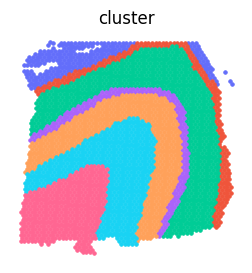

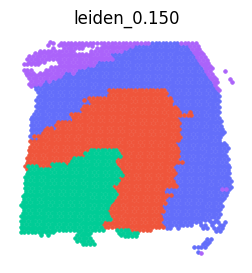

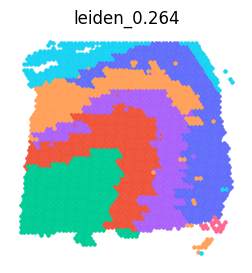

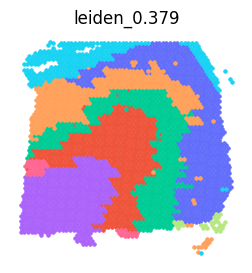

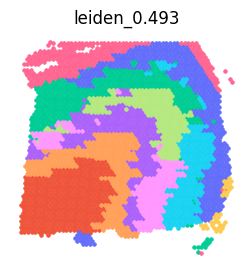

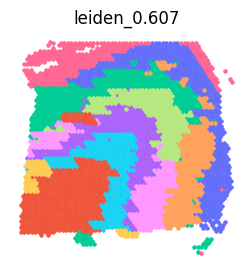

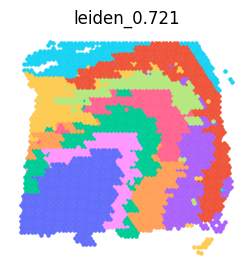

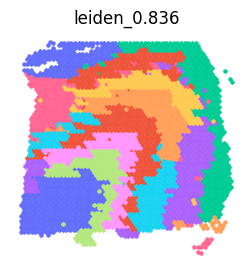

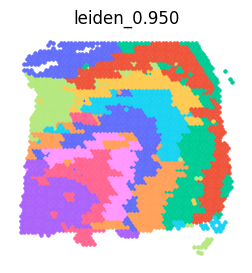

In [3]:

#Preprocess clusterings for each resolution
adata = phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE,emb=EMBEDDING,resolution=RESOLUTIONS,
                            res_keys=RES_KEYS,ground_truth=GROUND_TRUTH,neighbors=5,plots=True)


Constructing filtration...


100%|██████████| 7/7 [00:07<00:00,  1.07s/it]


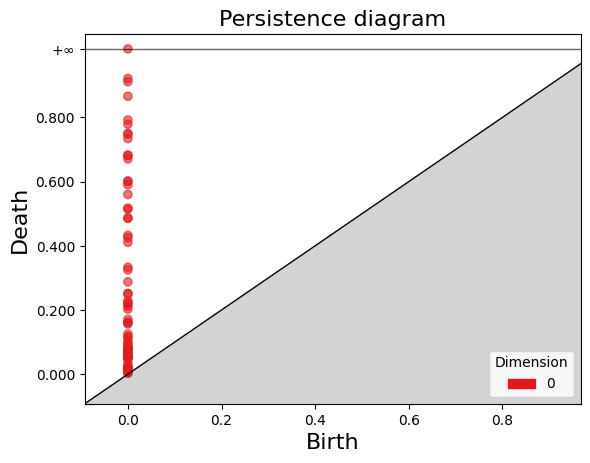

In [4]:
#Build cluster filtration
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='containment')

#Plot persistence diagram
from gudhi import plot_persistence_diagram
from gudhi import SimplexTree
plot_persistence_diagram(cluster_complex.persistence());


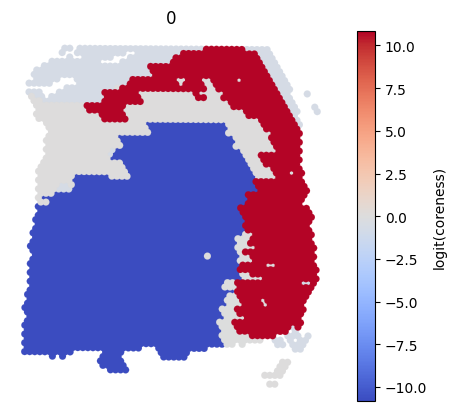

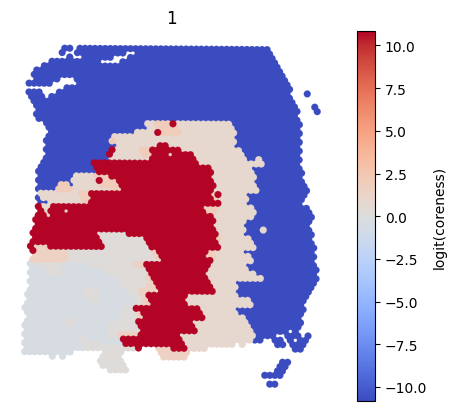

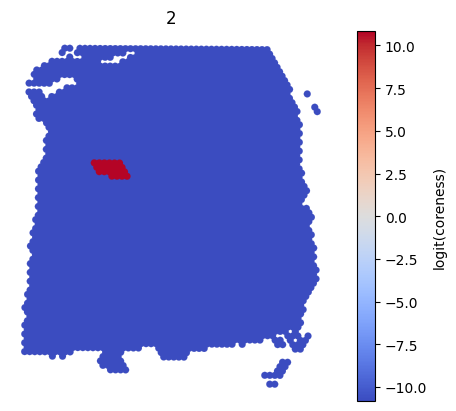

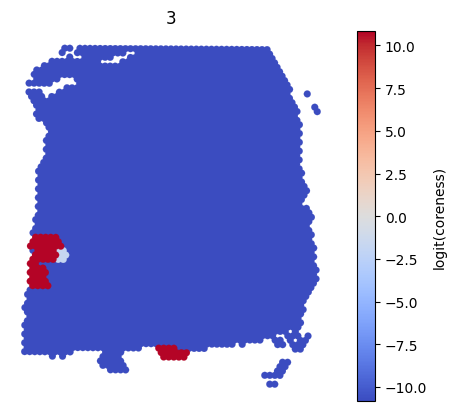

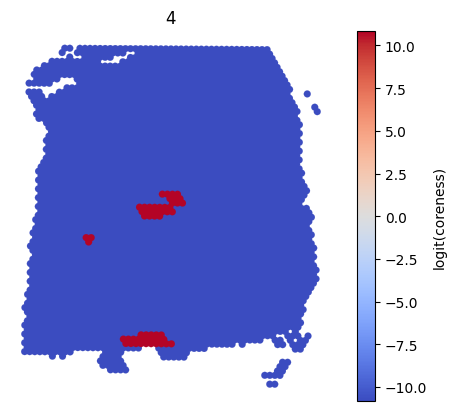

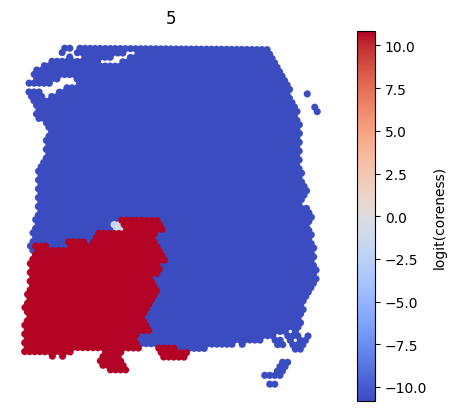

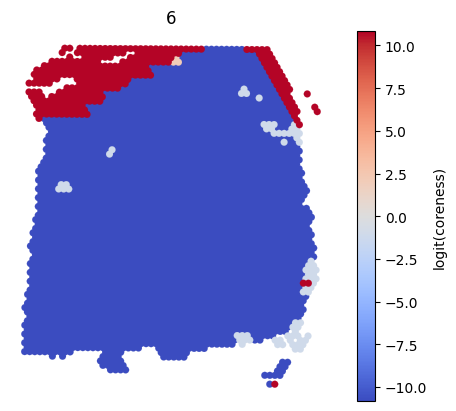

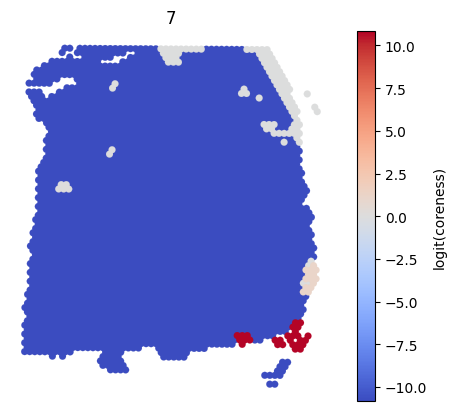

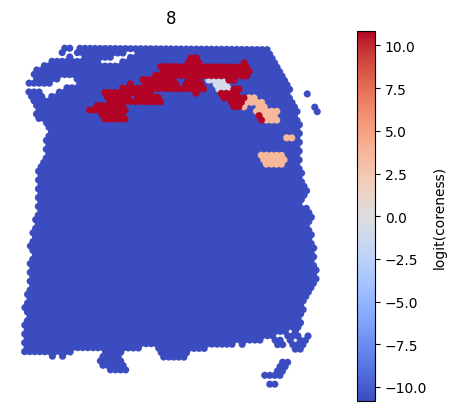

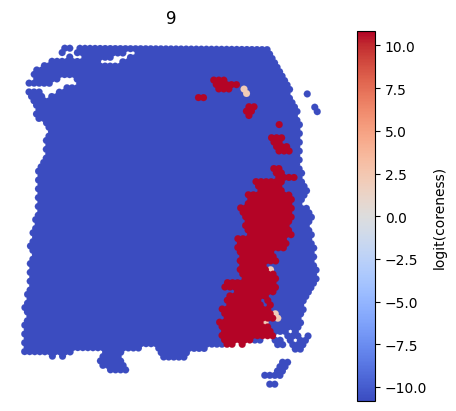

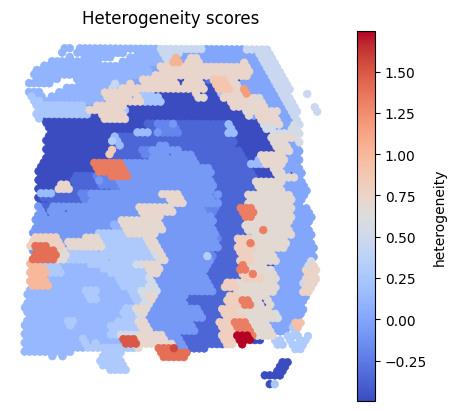

In [5]:

#map multiscale domains
phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=10,
                         order='persistence',plots='on');


computing wasserstein distances...


100%|██████████| 630/630 [00:46<00:00, 13.67it/s]


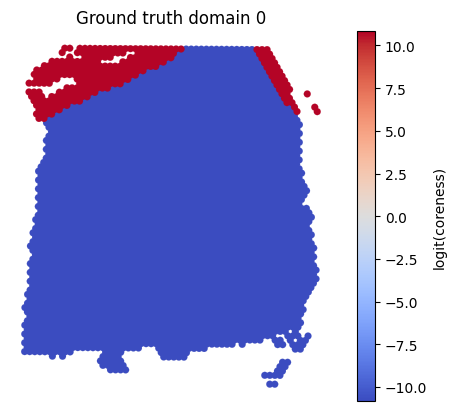

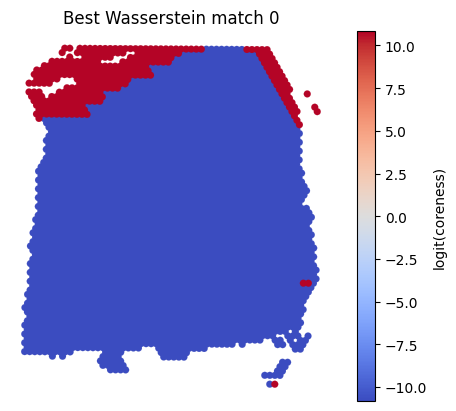

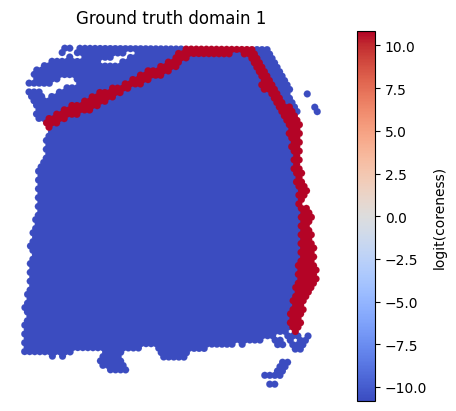

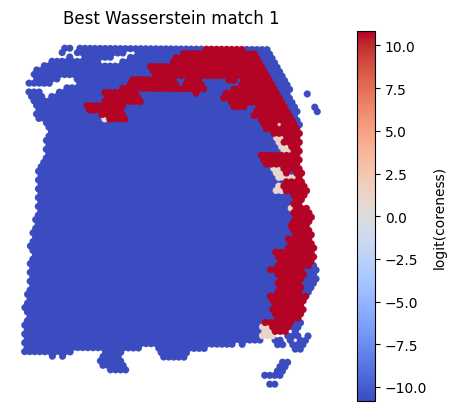

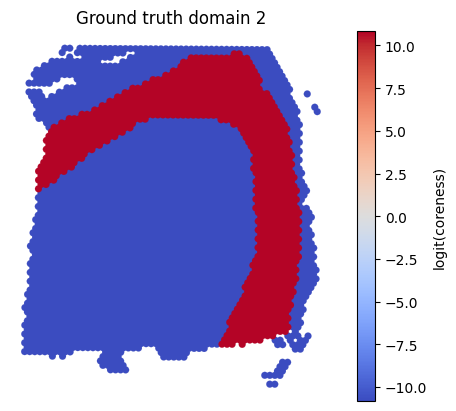

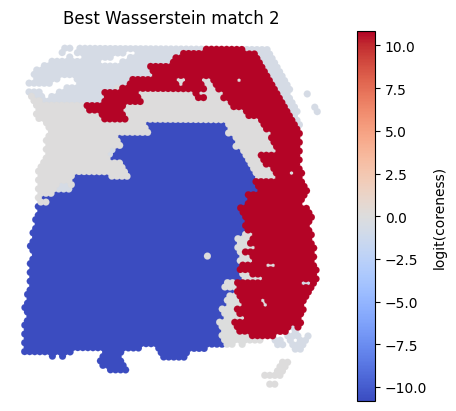

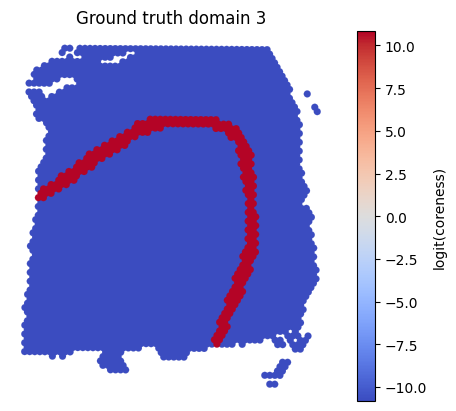

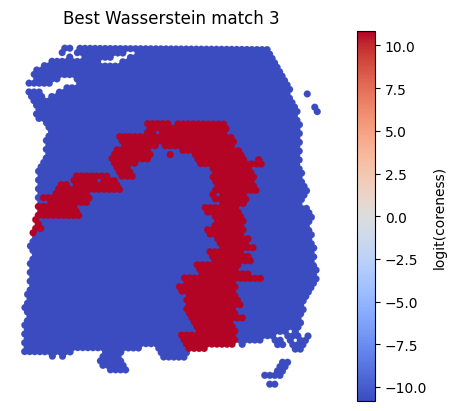

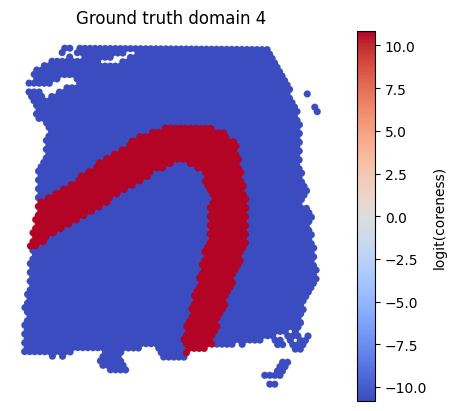

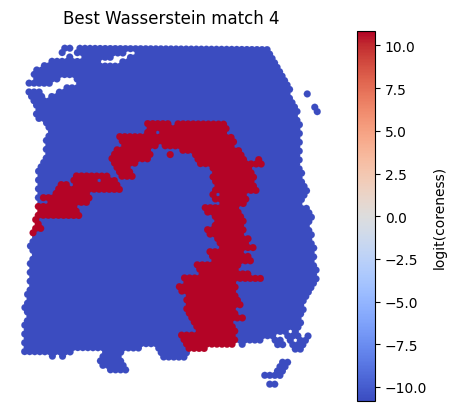

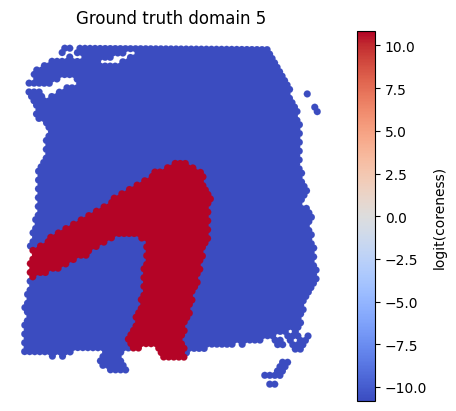

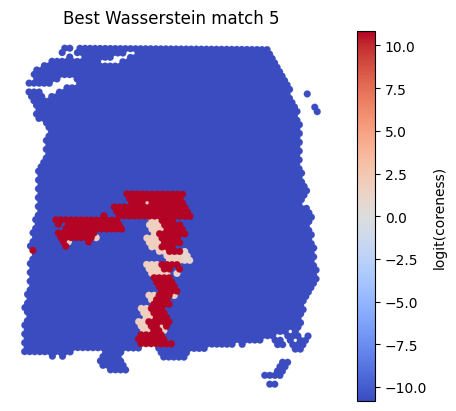

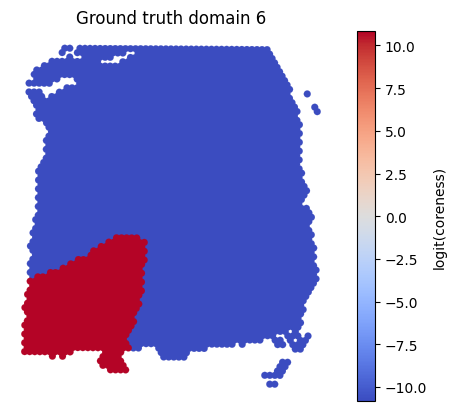

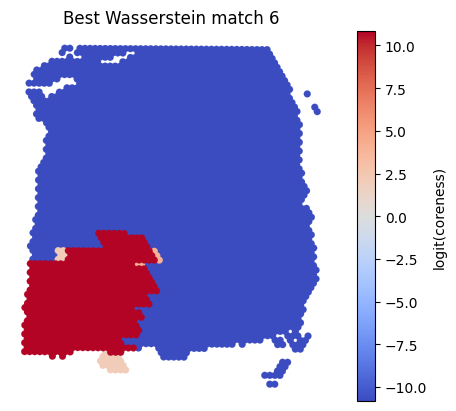

optimizing normalized mutual information...


100%|██████████| 50000/50000 [01:05<00:00, 768.89it/s]


NMI: 0.6390978488544814, MI: 1.0780828970586938


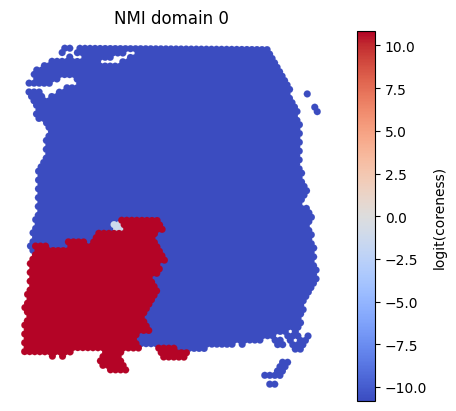

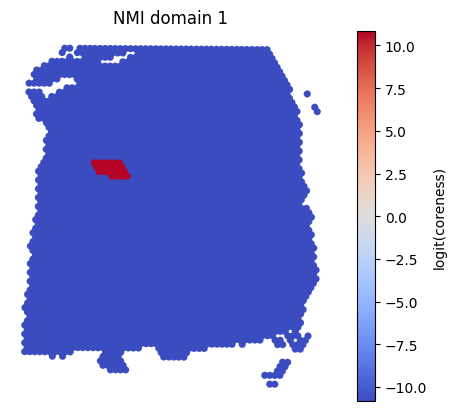

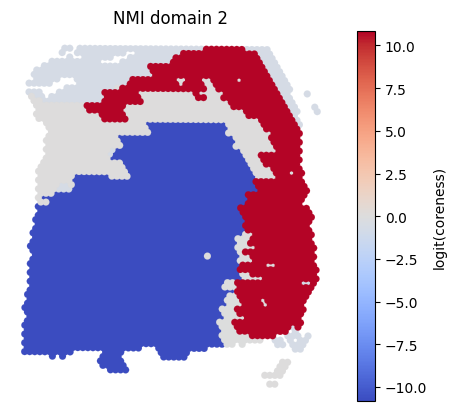

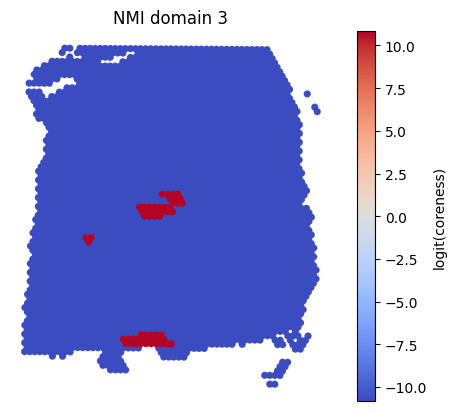

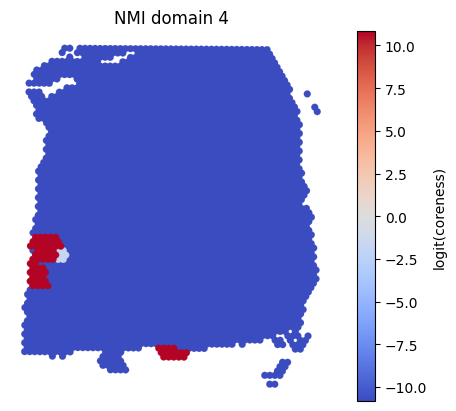

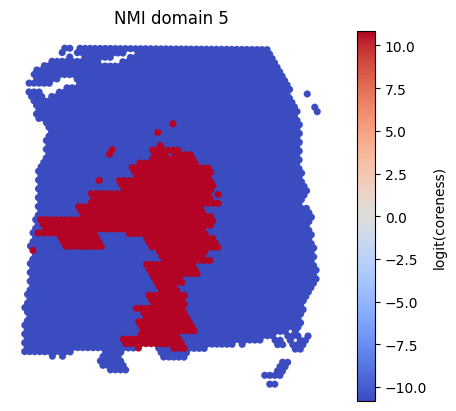

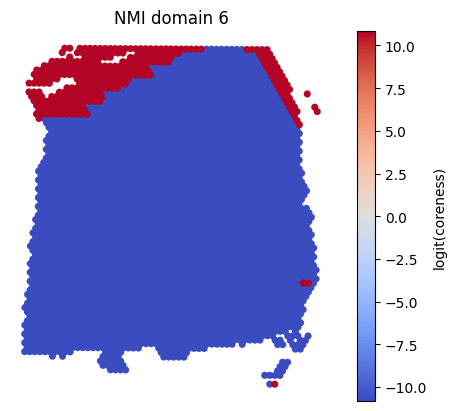

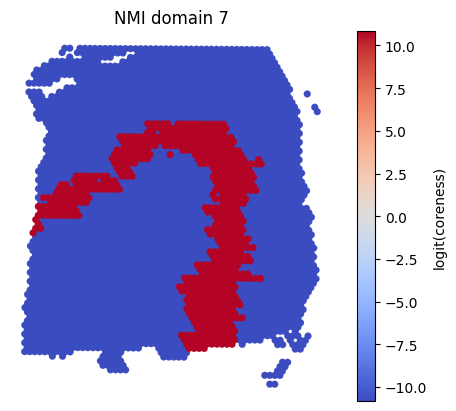

{'wasserstein costs': [np.float64(139.909805950578), np.float64(512.5119128531246), np.float64(283.489314177869), np.float64(671.446858985669), np.float64(452.4116917833374), np.float64(250.6872825073713), np.float64(114.43421314510647)], 'wasserstein matches': [np.int64(68), np.int64(23), np.int64(0), np.int64(48), np.int64(48), np.int64(24), np.int64(35)], 'nmi': np.float64(0.6390978488544814), 'nmi matches': [np.int64(5), np.int64(2), np.int64(0), np.int64(4), np.int64(3), np.int64(36), np.int64(75), np.int64(48)], 'mi': np.float64(1.0780828970586938)}


In [7]:
#Compute benchmark metrics
adata.obsm['multiscale']= phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='persistence',plots='off')
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obsm['multiscale'],adata.obsm['spatial'],plots=True,conversion_factor=16.435,metrics=['wasserstein','nmi'])
print(m)

In [14]:

#compare against single scale which best matches ground truth number of clusters
r = np.argmin(list(abs(len(adata.obs[GROUND_TRUTH].cat.categories.to_list()) - len(adata.obs[key].cat.categories.to_list())) for key in RES_KEYS))
r = RES_KEYS[r]
#Compute benchmarks for single scale clusters
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obs[r],adata.obsm['spatial'],plots=False,conversion_factor=16.435,metrics=['wasserstein','nmi'])
print(f'{m}')

computing wasserstein distances...


100%|██████████| 49/49 [00:03<00:00, 13.29it/s]


optimizing normalized mutual information...


100%|██████████| 50000/50000 [00:54<00:00, 925.12it/s]

NMI: 0.646297339518587, MI: 1.1511296205171873
{'wasserstein costs': [np.float64(157.4187855429721), np.float64(859.0986518087573), np.float64(870.0349379659076), np.float64(710.9612067739585), np.float64(610.2107417962349), np.float64(409.4256150461537), np.float64(271.83577328245923)], 'wasserstein matches': [np.int64(5), np.int64(0), np.int64(0), np.int64(3), np.int64(3), np.int64(1), np.int64(2)], 'nmi': np.float64(0.646297339518587), 'nmi matches': [np.int64(3), np.int64(1), np.int64(0), np.int64(4), np.int64(2), np.int64(6), np.int64(5)], 'mi': np.float64(1.1511296205171873)}
